In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
import koreanize_matplotlib

from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize, proportion_confint
from statsmodels.stats.power import NormalIndPower
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr

# ── 운영체제별 한글 폰트 설정 ──
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 전역 시드 설정 (재현성을 위해)
np.random.seed(42)

In [2]:
df = pd.read_csv('course_final.csv')

In [3]:
df.head()

,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,...,start_year,age_raw,age_missing_original,age_invalid,age_cleaned,age_final,age,age_group,exam_flag,LoE_num
0,HarvardX/PH207x/2012_Fall,MHxPC130275857,1,1,1,0,United States,unknown,NaN,unknown,...,2012,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
1,HarvardX/CB22x/2013_Spring,MHxPC130539455,1,1,0,0,France,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
2,HarvardX/CB22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
3,HarvardX/ER22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
4,HarvardX/ER22x/2013_Spring,MHxPC130198098,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN


### 1. 각 단계별 이탈이 심한 곳이 어디인가

In [4]:
stages = ['registered', 'viewed','explored']

df_funnel = df[stages].sum().reset_index()
df_funnel.columns = ['stages','user_count']

# 전체 유저 수
n = df_funnel.loc[0,'user_count']

df_funnel['step_conversion_rate'] = df_funnel['user_count'] / df_funnel['user_count'].shift(1)
df_funnel['cumulative_conversion_rate'] = df_funnel['user_count'] / n

df_funnel.loc[0,'step_conversion_rate'] = 1
df_funnel

,stages,user_count,step_conversion_rate,cumulative_conversion_rate
0,registered,533993,1.000000,1.000000
1,viewed,325361,0.609298,0.609298
2,explored,37584,0.115515,0.070383


In [5]:
import plotly.graph_objects as go

# https://simbbo-blog.tistory.com/185 참고
fig = go.Figure(go.Funnel(
    y=df_funnel['stages'],
    x=df_funnel['user_count'],
    textinfo="value+percent initial+percent previous",
    marker=dict(color=["#FF5733", "#FFC300", "#C70039", "#900C3F"]),
    hoverinfo = "y+x+percent initial+percent previous"
))

fig.update_layout(
    title='누적 생존율 및 단계별 전환율',
    yaxis_title='Stage'
)

fig.show()

1. explored에서 가장 많은 유저가 이탈함.

viewed -> explored의 전환율이 11% 가량으로 가장 많은 유저가 이탈하는 구간임

-> 이 부분에 대해서 중점적으로 보아야 하지 않을까.

재천님이 강의 별로 무언가를 보고 계신 것 같아서, 저는 전체에 대해서 확인해보려고 함

### 2. viewed -> explored, viewed ->(x) explored는 왜 차이가 존재할까

1. 인구 통계 정보에서는 학력이 가장 유의미할 것이고, 학력은 그래도 나이랑 관련한 무언가로 보아야 하지 않을까

2. 우선 학력이 더 우선일 것 같으니, 각 학력별로 카이제곱 검정을 진행

In [6]:
# Less than Secondary -> Secondary -> Bachelor's -> Master's -> Docterate
# 딱히 학위 순서에 따라서 무언가 달라지는 경향도 없어보임.
# 석사 + 박사를 묶어서 볼진 숫자 차이를 고려해야 함.
# 우선, 그냥 보는 게 좀 더 합리적으로 보임
df_viewed = df[df['viewed'] == 1]
df_viewed['LoE_DI'].value_counts()

LoE_DI
Bachelor's             105701
Secondary               84486
Master's                60554
unknown                 58669
Less than Secondary      7516
Doctorate                7377
Name: count, dtype: int64

In [7]:
# crosstab으로 확인했을 때는 각 비율 차이가 그렇게 커 보이진 않음.
ct = pd.crosstab(df_viewed['LoE_DI'], df_viewed['explored'])
display(ct)

explored,0,1
LoE_DI,,
Bachelor's,94899,10802
Doctorate,6426,951
Less than Secondary,6666,850
Master's,52513,8041
Secondary,75897,8589
unknown,50687,7982


In [8]:
# explored에서의 비율이 학력이 높아질 수록 조금 증가하는 것으로 보이긴 함.
# 코크란으로 보긴 해야할 듯? 만약에 순서 정보가 있는거라면.
for col in ct.T.columns:
    print(f'{col}에 대한 explored로 가는 도달률')
    print(f'{ct.T.loc[1,col] / sum(ct.T[col]):.4f}')
    print()

Bachelor's에 대한 explored로 가는 도달률
0.1022

Doctorate에 대한 explored로 가는 도달률
0.1289

Less than Secondary에 대한 explored로 가는 도달률
0.1131

Master's에 대한 explored로 가는 도달률
0.1328

Secondary에 대한 explored로 가는 도달률
0.1017

unknown에 대한 explored로 가는 도달률
0.1361



In [9]:
# 일단 단순하게 카이제곱 검정을 진행
# 검정 결과 p-value가 0.000으로 유의하다는 결론이 나오지만, 현재 데이터 크기를 고려했을 때 효과크기도 함께 확인할 필요성이 있음
chi2_stat, p_val, ddof, expected = chi2_contingency(ct)
print(f'검정 통계량 및 p-value : {chi2_stat:.4f}, {p_val:.4f}')
display(expected)
# 기대 빈도로 확인했을 때도 1000건 정도의 차이를 보이는데, 이게 과연 엄청나게 유의미한 결과인지는 생각해 볼 필요가 있음 

검정 통계량 및 p-value : 777.3418, 0.0000


array([[93571.40910815, 12129.59089185],
       [ 6530.46125383,   846.53874617],
       [ 6653.51047631,   862.48952369],
       [53605.19869381,  6948.80130619],
       [74790.91087039,  9695.08912961],
       [51936.50959751,  6732.49040249]])

[[94899 10802]
 [ 6426   951]
 [ 6666   850]
 [52513  8041]
 [75897  8589]
 [50687  7982]]


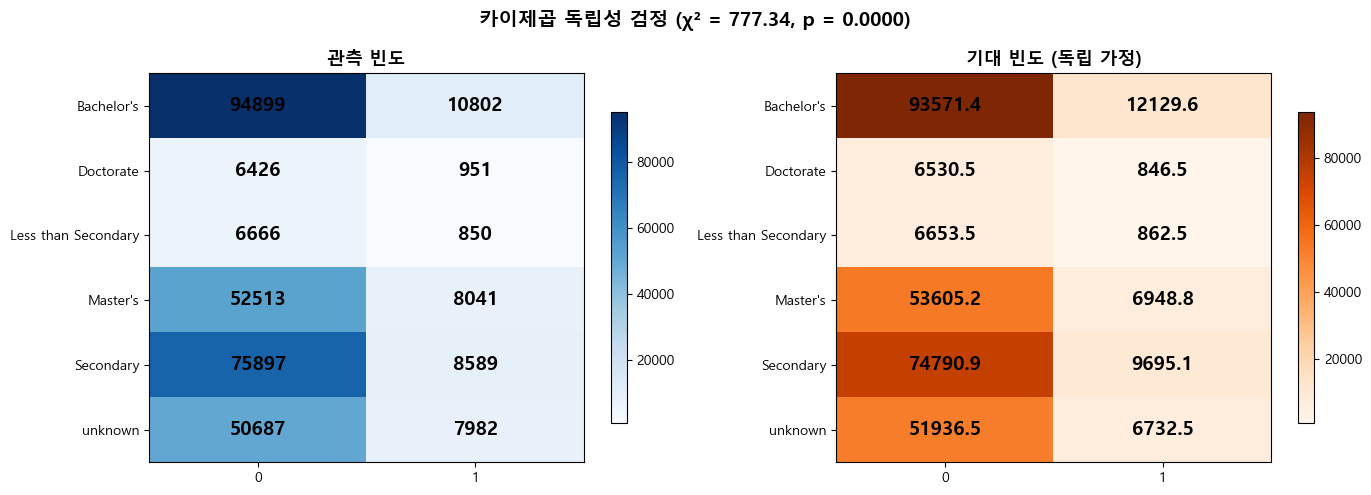

In [10]:
#### 무아 튜터님 자료 그대로 복붙(솔직하게 보고용 이쁘게 만든 자료. 필요없긴함)
# ── 시각화: 교차표 히트맵 ──
# 관측 빈도 히트맵
ct_raw = ct
ct_obs = ct_raw.values
print(ct_obs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(ct_obs, cmap='Blues', aspect='auto')
axes[0].set_title('관측 빈도', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(len(ct_raw.columns)))
axes[0].set_xticklabels(ct_raw.columns)
axes[0].set_yticks(range(len(ct_raw.index)))
axes[0].set_yticklabels(ct_raw.index)
for i in range(ct_obs.shape[0]):
    for j in range(ct_obs.shape[1]):
        axes[0].text(j, i, f'{ct_obs[i, j]}', ha='center', va='center',
                    fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# 기대 빈도 히트맵
im2 = axes[1].imshow(expected, cmap='Oranges', aspect='auto')
axes[1].set_title('기대 빈도 (독립 가정)', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(ct.columns)))
axes[1].set_xticklabels(ct_raw.columns)
axes[1].set_yticks(range(len(ct.index)))
axes[1].set_yticklabels(ct.index)
for i in range(expected.shape[0]):
    for j in range(expected.shape[1]):
        axes[1].text(j, i, f'{expected[i, j]:.1f}', ha='center', va='center',
                    fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[1], shrink=0.8)

fig.suptitle(f"카이제곱 독립성 검정 (χ² = {chi2_stat:.2f}, p = {p_val:.4f})",
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### 카이제곱 검정 효과 크기

| 효과크기 | 적용 검정 | 공식 | 공식 의미 | Python 라이브러리 | 해석 기준 (small / medium / large) |
|----------|----------|------|----------|-------------------|--------------------------------------|
| **Cohen's w** | 카이제곱 적합도 | √(χ² / N) | 관측 빈도와 기대 빈도의 **표준화된 괴리 정도** (0~∞) | `np.sqrt(chi2 / n)` | 0.1 / 0.3 / 0.5 |
| **Cramér's V** | 카이제곱 독립성 | √(χ² / (N · min(r−1, c−1))) | 두 범주형 변수 간 **연관성의 강도** (0~1) | `association(ct.values, method='cramer')` | df*에 따라 다름 † |

> † **Cramér's V 해석 기준** (Cohen 관례) \
> Small = 0.1/√df*, Medium = 0.3/√df*, Large = 0.5/√df* \
> (df* = min(r−1, c−1))
> | df* | Small | Medium | Large |
> |-----|-------|--------|-------|
> | 1 (2×2) | 0.10 | 0.30 | 0.50 |
> | 2 | 0.07 | 0.21 | 0.35 |
> | 3 | 0.06 | 0.17 | 0.29 |

In [11]:
# 효과 크기가 그렇게 크지 않음.
# 결국, 각 집단 별로 explored에 실패한 집단에서의 차이가 크지 않다는 얘기
from scipy.stats.contingency import association

cramers_v = association(ct.values, method = 'cramer')
print(f'검정의 효과크기 : {cramers_v:.4f}')

검정의 효과크기 : 0.0490


학위에 따라 explored로 넘어가는 구간은 통계적으로 유의하지만, 효과크기를 고려했을 때 큰 차이는 없다고 결론내릴 수 있다.

이후 다음 스텝이 필요한지에 대해서는 좀 더 고민해봐야 함.

1. 아까 학위 정보에 따라 도달률이 그래도 선형적인 패턴을 보임. 
-> 코크란 검정을 통해 순서 반영한다던지, 혹은 석사를 기준으로 나눠서 두 집단만 비교를 해보던지

2. 아니면 여기에 힘을 빼고 행동정보에 시간을 더 쓴다던지

3. 혹은 다변량에서 나이 정보까지 함께 반영해서 본다던지

무튼 결론은 **학위 정보**는 통계적으로 유의미하지만, 효과크기를 고려했을 때 아주 약한 효과크기를 보인다.

-> 그래서, 굳이 이걸 KPI로까지 이어갈 필요가 없을 것 같다.
(다만, 그래도 유저 기본 정보이니 대시보드에는 넣을 수도 있다 + 유의미하지 않더라도 대시보드에 넣는게 의미가 있다면 계산해서 넣는다.)

-> 혹은 추후에 이탈률에 대한 그룹화 시 차이가 있다면 다변량으로 연결해도 된다.

### 2.2 last_event_DI 이탈율 관련

1. 두 그룹 별 중위수의 수명 비교

In [21]:
df_fail_explored = df_viewed[df_viewed['explored'] == 0]
df_suc_explored = df_viewed[df_viewed['explored'] == 1]

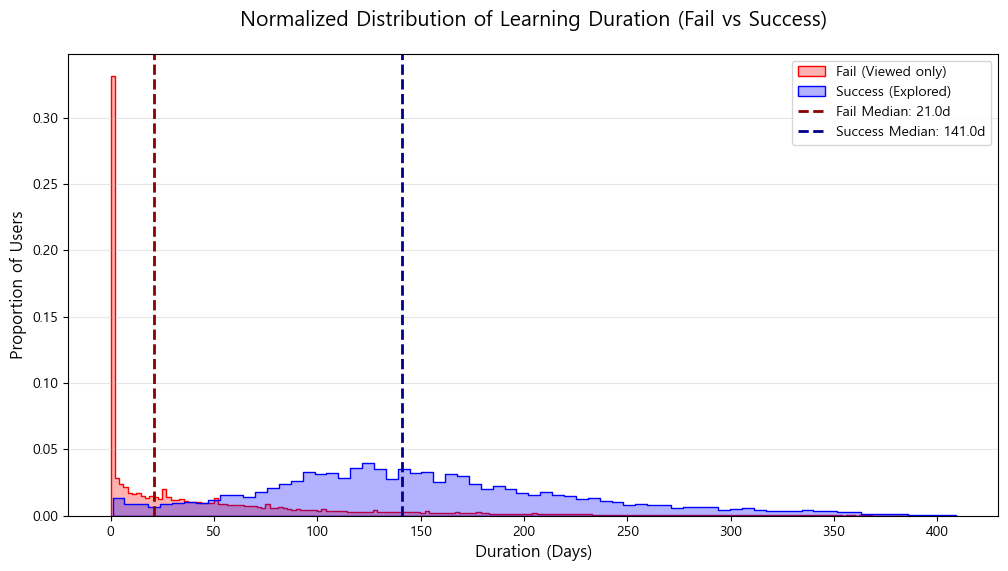

In [ ]:
median_fail = df_fail_explored['duration'].median()
median_suc = df_suc_explored['duration'].median()

plt.figure(figsize=(12, 6))

# 성공/실패 그룹의 비율(Proportion) 비교
# common_norm=False를 해야 각 그룹별로 100% 기준이 잡힙니다.
sns.histplot(data=df_fail_explored, x='duration', color='red', label='Fail (Viewed only)', 
            stat='proportion', common_norm=False, alpha=0.3, element="step")

sns.histplot(data=df_suc_explored, x='duration', color='blue', label='Success (Explored)', 
            stat='proportion', common_norm=False, alpha=0.3, element="step")

# 중앙값 표시
plt.axvline(median_fail, color='darkred', linestyle='--', linewidth=2, label=f'Fail Median: {median_fail}d')
plt.axvline(median_suc, color='darkblue', linestyle='--', linewidth=2, label=f'Success Median: {median_suc}d')

# 그래프 디테일
plt.title('Normalized Distribution of Learning Duration (Fail vs Success)', fontsize=15, pad=20)
plt.xlabel('Duration (Days)', fontsize=12)
plt.ylabel('Proportion of Users', fontsize=12) # Y축이 이제 비율(0~1)로 바뀝니다.
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

- 단순히 그림만 보더라도, 통계 검정까지 갈 필요 없이 전체 수강일이 길 수록 강의를 열심히 수강하는 그룹이 늘어남

- explored까지 가려면 결국 초기 이탈을 어디에서 잡을 수 있을지를 확인해야 함

In [57]:
# viewed 그룹에서 어디에서 많이 이탈하는가
df_proportion = df_fail_explored.value_counts('duration').reset_index().sort_values('duration')
df_proportion['proportion'] = df_proportion['count'] / len(df_fail_explored)
df_proportion['fail_rate'] = 1 - df_proportion['proportion'].cumsum()
df_proportion

df_proportion['duration'] = df_proportion['duration'] + 1
start_point = pd.DataFrame({'duration':[0], 'fail_rate':[1.0]})
df_plot = pd.concat([start_point, df_proportion]).sort_values('duration').reset_index(drop = True)
df_plot.head(30)

,duration,fail_rate,count,proportion
0,0,1.000000,NaN,NaN
1,1,0.762766,68107.0,0.237234
2,2,0.689987,20894.0,0.072779
3,3,0.668300,6226.0,0.021687
4,4,0.652775,4457.0,0.015525
5,5,0.639567,3792.0,0.013208
6,6,0.627595,3437.0,0.011972
7,7,0.615654,3428.0,0.011941
8,8,0.603881,3380.0,0.011773
9,9,0.593658,2935.0,0.010223


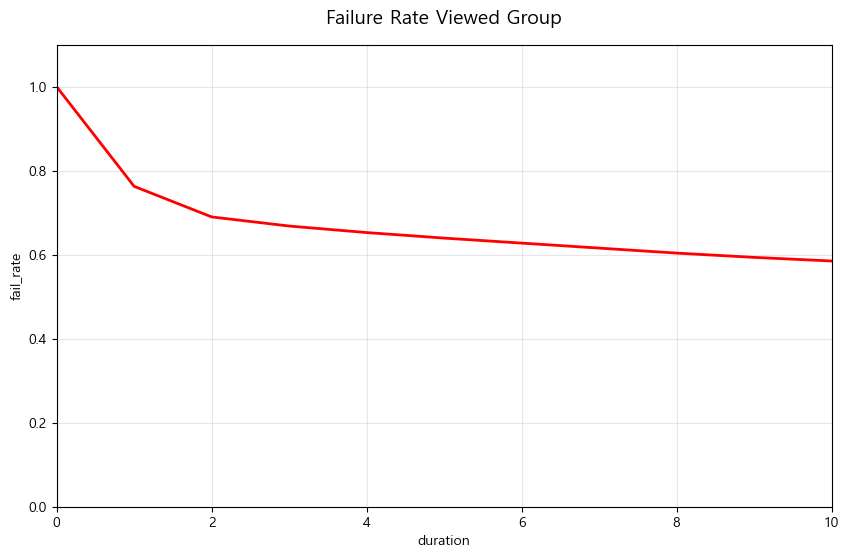

In [61]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_plot, x='duration', y='fail_rate', color='red', linewidth=2)

plt.xlim(0, 10)
plt.ylim(0, 1.1) 
plt.title('Failure Rate Viewed Group', fontsize=14, pad=15)
plt.grid(True, alpha=0.3)

plt.show()

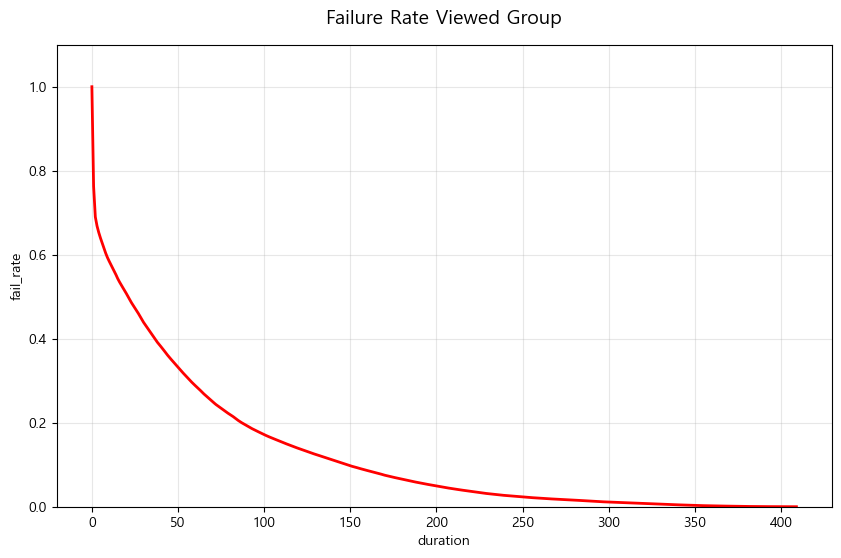

In [62]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_plot, x='duration', y='fail_rate', color='red', linewidth=2)

plt.ylim(0, 1.1) 
plt.title('Failure Rate Viewed Group', fontsize=14, pad=15)
plt.grid(True, alpha=0.3)

plt.show()

(0.0, 200.0)

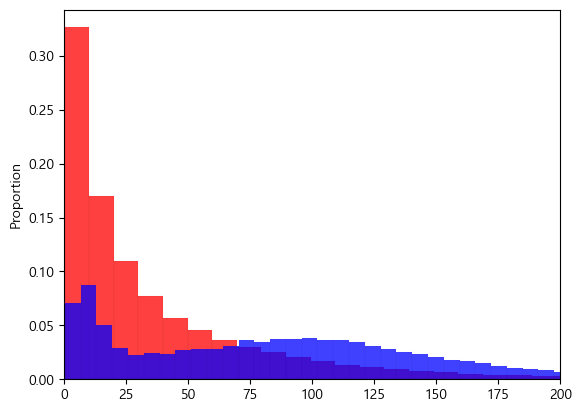

In [70]:
df_fail_explored = df_viewed[df_viewed['explored'] == 0]
df_suc_explored = df_viewed[df_viewed['explored'] == 1]

sns.histplot(df_fail_explored['nevents'] / df_fail_explored['ndays_act'], color = 'red', stat = 'proportion')
sns.histplot(df_suc_explored['nevents'] / df_suc_explored['ndays_act'], color = 'blue', stat = 'proportion')

plt.xlim(0,200)

In [71]:
from scipy import stats

# 1. 두 그룹의 변수 정의 (결측치가 있다면 dropna()를 꼭 해주세요)
fail_density = (df_fail_explored['nevents'] / df_fail_explored['ndays_act']).dropna()
suc_density = (df_suc_explored['nevents'] / df_suc_explored['ndays_act']).dropna()

# 2. 맨-휘트니 U 검정 실행 (대립가설: suc_density가 fail_density보다 크다)
stat, p_val = stats.mannwhitneyu(suc_density, fail_density, alternative='greater')

# 3. 각 그룹의 중앙값 확인 (보고서 작성용)
print(f"이탈 그룹(Fail) 일평균 클릭수 중앙값: {fail_density.median():.1f}회")
print(f"수료 그룹(Success) 일평균 클릭수 중앙값: {suc_density.median():.1f}회")
print("-" * 30)
print(f"Mann-Whitney U 통계량: {stat}")
print(f"P-value: {p_val}")

if p_val < 0.05:
    print("결론: 두 그룹 간의 일평균 몰입도(클릭수)는 통계적으로 유의미한 차이가 있습니다.")
else:
    print("결론: 통계적으로 유의미한 차이가 없습니다.")

이탈 그룹(Fail) 일평균 클릭수 중앙값: 20.0회
수료 그룹(Success) 일평균 클릭수 중앙값: 84.0회
------------------------------
Mann-Whitney U 통계량: 7919003168.0
P-value: 0.0
결론: 두 그룹 간의 일평균 몰입도(클릭수)는 통계적으로 유의미한 차이가 있습니다.


In [72]:
# stat은 아까 구한 Mann-Whitney U 통계량
n1 = len(suc_density)
n2 = len(fail_density)

# 효과크기 (Rank-Biserial Correlation) 계산
effect_size = 1 - (2 * stat) / (n1 * n2)
print(f"효과크기 (Effect Size): {abs(effect_size):.3f}")

효과크기 (Effect Size): 0.482


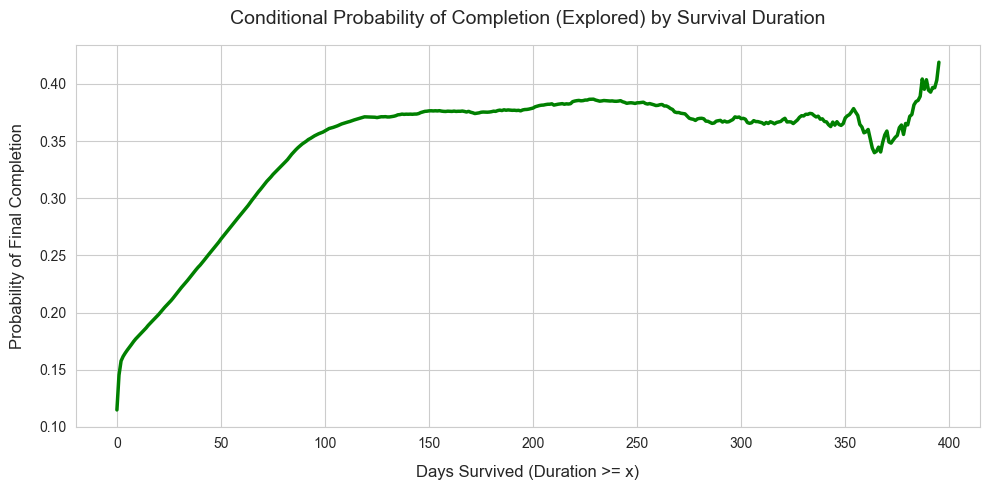

In [75]:
conditional_results = []
max_days = int(df_viewed['duration'].max())

# x일보다 적은 구간은 제외하면서 그래프를 그려봄
for x in range(max_days + 1):
    survivors = df_viewed[df_viewed['duration'] >= x]

    if len(survivors) > 100:
        success_count = survivors['explored'].sum()
        prob = success_count / len(survivors)

        conditional_results.append({'day' : x, 'cond_prob': prob, 'sample_size': len(survivors)})
df_cond = pd.DataFrame(conditional_results)


plt.figure(figsize=(10, 5))
sns.set_style("whitegrid") 

sns.lineplot(data=df_cond, x='day', y='cond_prob', color='green', linewidth=2.5)

plt.title('Conditional Probability of Completion (Explored) by Survival Duration', fontsize=14, pad=15)
plt.xlabel('Days Survived (Duration >= x)', fontsize=12, labelpad=10)
plt.ylabel('Probability of Final Completion', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()